# 1. Title and Goal
Satellite Image Classification

This project classifies satellite images into four classes: cloudy, desert, green_area, and water.
Models compared:
1. Custom CNN
2. MobileNetV2

#2. Dataset source
Source: Kaggle - Satellite Image Classification (https://www.kaggle.com/datasets/mahmoudreda55/satellite-image-classification/code/data)

Classes:
- cloudy
- desert
- green_area
- water

#3. Imports

In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Rescaling, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report
from tensorflow.keras.applications import MobileNetV2

#4. Mount Drive and dataset path

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_DIR = '/content/drive/MyDrive/data'

IMG_SIZE=128
BATCH_SIZE=32
SEED=42
EPOCHS=15

Mounted at /content/drive


#5. Load dataset

In [ ]:
train_ds=tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds=tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(class_names)

Found 5631 files belonging to 4 classes.
Using 4505 files for training.
Found 5631 files belonging to 4 classes.
Using 1126 files for validation.
['cloudy', 'desert', 'green_area', 'water']


#6. Data inspection

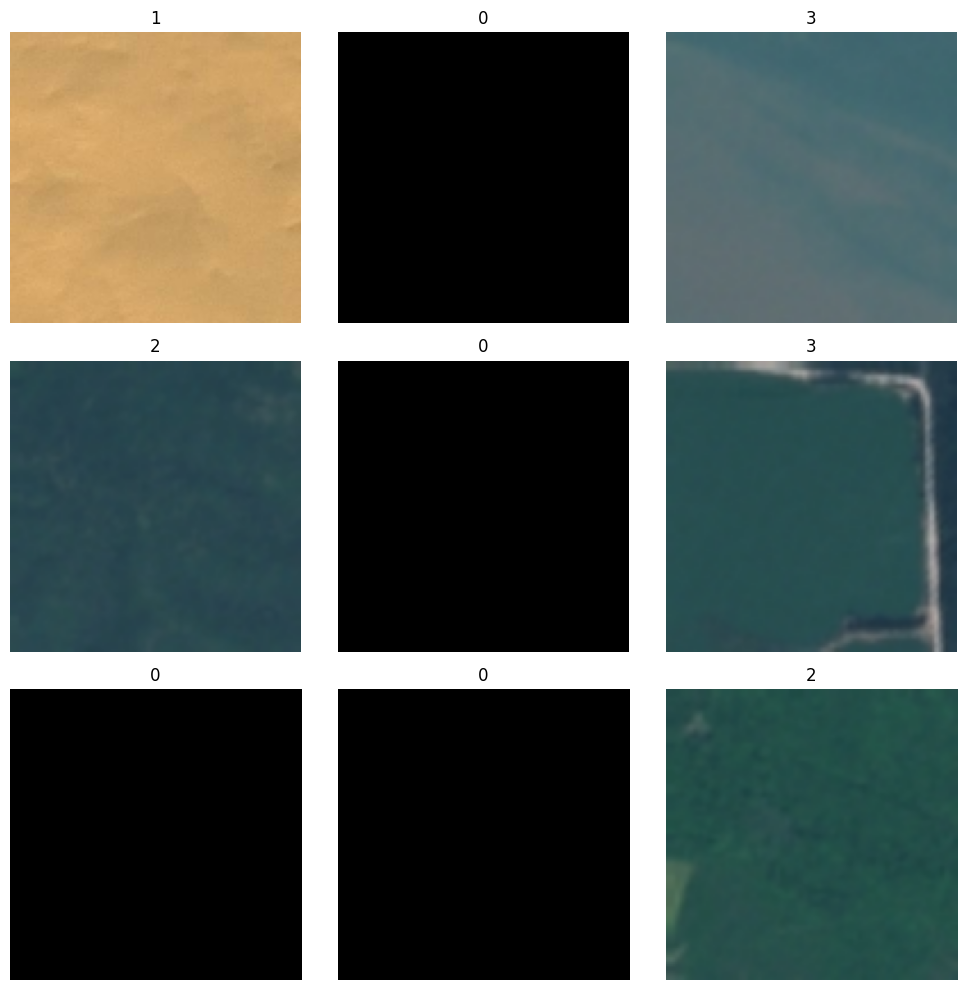

In [ ]:
# show images
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
  for i in range(9):
      ax=plt.subplot(3,3,i+1)
      plt.imshow(images[i].numpy().astype('uint8'))
      plt.title(int(labels[i]))
      plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# shapes
for image_batch, labels_batch in train_ds.take(1):
    print("image shape:",images.shape)
    print("label shape:",labels.shape)

image shape: (32, 128, 128, 3)
label shape: (32,)


In [ ]:
# class counts
counter = Counter()
class_names = train_ds.class_names
for _, labels in train_ds:
    counter.update(labels.numpy())

for idx, count in counter.items():
    print(class_names[idx], ":", count)

green_area : 1182
desert : 907
cloudy : 1233
water : 1183


In [ ]:
# pixel values
for images, _ in train_ds.take(1):
    print("Min pixel:", tf.reduce_min(images).numpy())
    print("Max pixel:", tf.reduce_max(images).numpy())

Min pixel: 0.0
Max pixel: 206.75


#7. Data Pipeline Optimization

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

#8. Model 1: Custom CNN

## Custom CNN

In [ ]:
# Augmentation
data_augmentation = Sequential([
    Rescaling(1./255),
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1)
])

In [ ]:
# build model
num_classes = len(class_names)

cnn_model = tf.keras.Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    data_augmentation,

    Conv2D(16, 3, activation="relu", padding="same"),
    MaxPooling2D(),

    Conv2D(32, 3, activation="relu", padding="same"),
    MaxPooling2D(),

    Conv2D(64, 3, activation="relu", padding="same"),
    MaxPooling2D(),

    Flatten(),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(num_classes, activation="softmax")
])

In [ ]:
# compile
cnn_model.compile(
    optimizer=Adam(0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,048,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,072,484 (4.09 MB)

 Trainable params: 1,072,484 (4.09 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# callback
cnn_callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ModelCheckpoint("best_cnn_model.keras", save_best_only=True)
]

In [ ]:
# train
cnn_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cnn_callbacks
)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 251s 2s/step - accuracy: 0.7931 - loss: 0.4199 - val_accuracy: 0.8934 - val_loss: 0.2434
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 60s 424ms/step - accuracy: 0.8961 - loss: 0.2309 - val_accuracy: 0.8108 - val_loss: 0.3319
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 62s 437ms/step - accuracy: 0.9125 - loss: 0.2025 - val_accuracy: 0.9174 - val_loss: 0.1904
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 79s 414ms/step - accuracy: 0.9223 - loss: 0.1753 - val_accuracy: 0.9005 - val_loss: 0.2907
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 58s 415ms/step - accuracy: 0.9336 - loss: 0.1628 - val_accuracy: 0.9236 - val_loss: 0.1606
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 84s 426ms/step - accuracy: 0.9307 - loss: 0.1577 - val_accuracy: 0.9156 - val_loss: 0.2118
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 59s 419ms/step - accuracy: 0.9165 - loss: 0.1916 - val_accuracy: 0.9130 - val_loss: 0.1758
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 57s 403ms/step - accuracy: 0.9276 - loss: 0.1

#9. CNN results

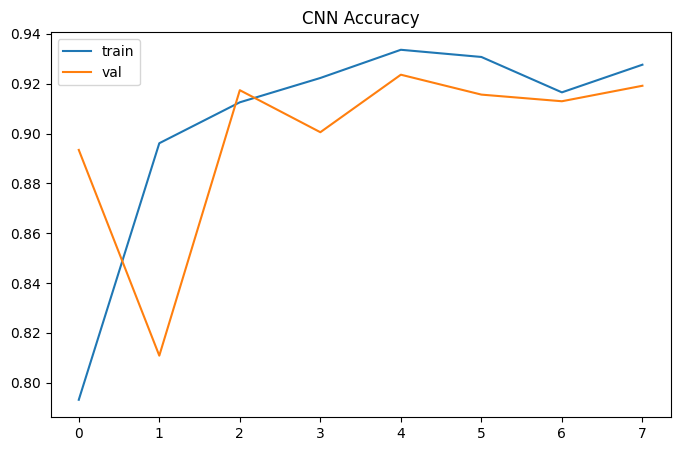

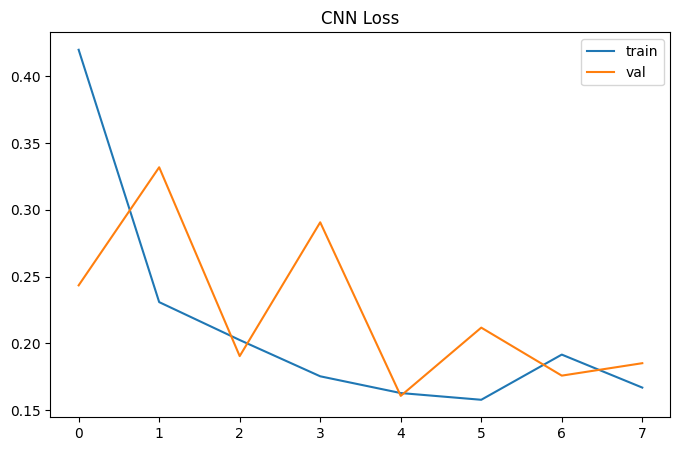

In [ ]:
# plots
plt.figure(figsize=(8,5))
plt.plot(cnn_history.history["accuracy"], label="train")
plt.plot(cnn_history.history["val_accuracy"], label="val")
plt.legend()
plt.title("CNN Accuracy")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(cnn_history.history["loss"], label="train")
plt.plot(cnn_history.history["val_loss"], label="val")
plt.legend()
plt.title("CNN Loss")
plt.show()

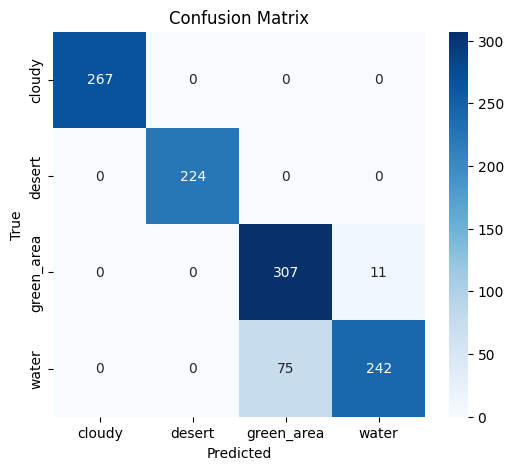

              precision    recall  f1-score   support

      cloudy       1.00      1.00      1.00       267
      desert       1.00      1.00      1.00       224
  green_area       0.80      0.97      0.88       318
       water       0.96      0.76      0.85       317

    accuracy                           0.92      1126
   macro avg       0.94      0.93      0.93      1126
weighted avg       0.93      0.92      0.92      1126



In [ ]:
# confusion matrix+report
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = cnn_model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

# 10. Model 2: MobileNetV2

In [ ]:
base_model = MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(32, activation="relu")(x)
x = tf.keras.layers.Dense(4, activation="softmax")(x)

mobilenet_model = tf.keras.Model(inputs=base_model.input, outputs=x)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# compile
mobilenet_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

*The custom CNN was trained for more epochs as it learns from scratch, while MobileNetV2 requires fewer epochs due to pretrained feature representations.*

In [ ]:
# train
mobilenet_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 51s 332ms/step - accuracy: 0.9614 - loss: 0.1436 - val_accuracy: 0.9876 - val_loss: 0.0419
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 43s 308ms/step - accuracy: 0.9940 - loss: 0.0271 - val_accuracy: 0.9938 - val_loss: 0.0225
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 44s 309ms/step - accuracy: 0.9962 - loss: 0.0185 - val_accuracy: 0.9920 - val_loss: 0.0188
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 44s 316ms/step - accuracy: 0.9962 - loss: 0.0140 - val_accuracy: 0.9938 - val_loss: 0.0186
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 80s 305ms/step - accuracy: 0.9958 - loss: 0.0128 - val_accuracy: 0.9947 - val_loss: 0.0156
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 44s 310ms/step - accuracy: 0.9945 - loss: 0.0154 - val_accuracy: 0.9938 - val_loss: 0.0129
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 43s 305ms/step - accuracy: 0.9958 - loss: 0.0128 - val_accuracy: 0.9947 - val_loss: 0.0141
Epoch 8/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 82s 308ms/step - accuracy: 0.9967 - loss: 0

#11. MobileNet results

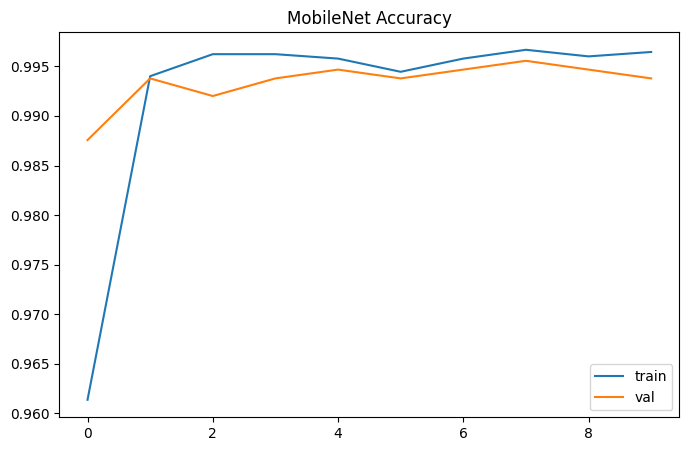

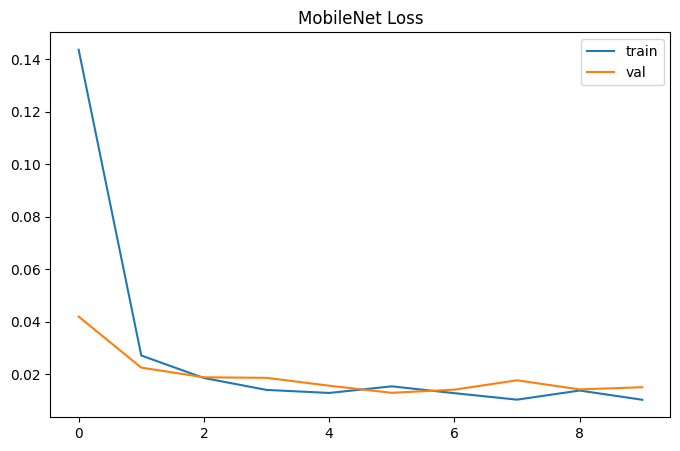

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(mobilenet_history.history["accuracy"], label="train")
plt.plot(mobilenet_history.history["val_accuracy"], label="val")
plt.legend()
plt.title("MobileNet Accuracy")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(mobilenet_history.history["loss"], label="train")
plt.plot(mobilenet_history.history["val_loss"], label="val")
plt.legend()
plt.title("MobileNet Loss")
plt.show()

#12. Final Comparison

## Model Comparison

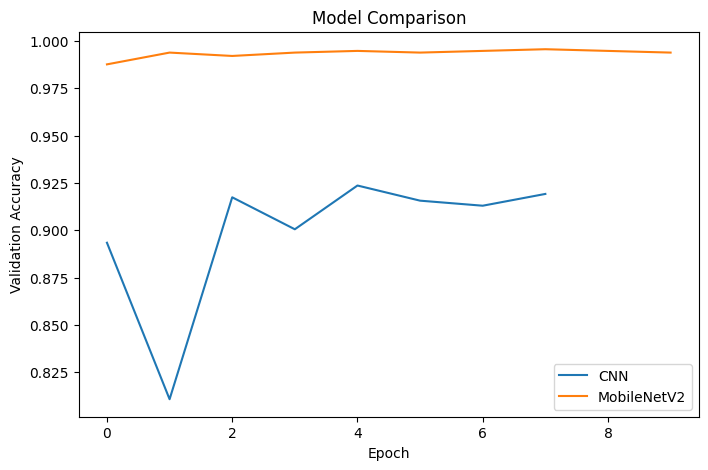

In [ ]:
# comparison graph
plt.figure(figsize=(8,5))
plt.plot(cnn_history.history["val_accuracy"], label="CNN")
plt.plot(mobilenet_history.history["val_accuracy"], label="MobileNetV2")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Model Comparison")
plt.legend()
plt.show()

 The custom CNN learns from scratch and achieves good performance.
 MobileNetV2 uses pretrained features and achieves higher and more stable validation accuracy.

#13. Saving the outputs

## Saving Model and results

In [ ]:
cnn_model.save("/content/drive/MyDrive/best_cnn_final.keras")
mobilenet_model.save("/content/drive/MyDrive/best_mobilenet_final.keras")

In [ ]:
with open("/content/drive/MyDrive/class_names.json", "w") as f:
    json.dump(class_names, f)